# 02 — Tiền xử lý dữ liệu NIH ChestX-ray14

## Thành viên 02 — Dataset & Preprocessing

Notebook này thực hiện toàn bộ quy trình chuẩn bị dữ liệu cho bài toán
**ước lượng tuổi bệnh nhân từ ảnh X-quang ngực** sử dụng bộ dữ liệu
**NIH ChestX-ray14**.

### Quy trình xử lý

NIH ChestX-ray14  
→ Đọc Metadata  
→ Làm sạch Patient Age  
→ Liên kết Metadata với ảnh X-ray  
→ Patient-level Split  
→ Train / Validation / Test  
→ Exploratory Data Analysis (EDA)  
→ Image Preprocessing  
→ PyTorch Dataset & DataLoader

### Mục tiêu

Sau khi hoàn thành notebook, dữ liệu phải đáp ứng:

- Dữ liệu được chia theo **Patient ID**, không chia ngẫu nhiên theo từng ảnh.
- Không có bệnh nhân xuất hiện đồng thời ở Train, Validation và Test.
- Các giá trị tuổi không hợp lệ được loại bỏ.
- Ảnh được đọc trực tiếp từ file ZIP mà không cần giải nén toàn bộ dataset.
- Ảnh đầu vào CNN có kích thước `[1, 224, 224]`.
- DataLoader trả về batch ảnh `[B, 1, 224, 224]`.
- Target tuổi có kích thước `[B, 1]`.

## 1. Thiết lập môi trường và đường dẫn

### Mục đích

Bước đầu tiên là khai báo các thư viện và đường dẫn được sử dụng trong
toàn bộ pipeline.

Dataset NIH ChestX-ray14 được lưu dưới dạng `archive.zip`. Thay vì giải
nén toàn bộ dataset, notebook sẽ sử dụng thư viện `zipfile` để truy cập
metadata và từng ảnh trực tiếp bên trong file ZIP.

Cách làm này giúp:

- Tiết kiệm dung lượng ổ đĩa.
- Không tạo thêm một bản sao lớn của dataset.
- Vẫn có thể truy cập từng ảnh khi PyTorch Dataset yêu cầu.
- Giữ dữ liệu gốc ở trạng thái không thay đổi.

Các file sinh ra sau preprocessing sẽ được lưu trong thư mục
`data/processed`.

In [26]:
import io
import random
from PIL import Image
from pathlib import Path
import sys, zipfile
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

PROJECT_ROOT = Path(r"Q:\Deep_Learning\UTH-Deep-Learning-nhom2\CourseWork\Member_02_Data")
ZIP_PATH = PROJECT_ROOT / "data" / "data NIH xray14" / "archive.zip"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

SRC_DIR = PROJECT_ROOT / "src"
sys.path.append(str(SRC_DIR))

from preprocess import load_metadata_from_zip, clean_age, build_image_index, attach_zip_paths, patient_level_split, save_splits, split_summary
from dataset import ZipChestXrayAgeDataset, default_transform

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print("ZIP:", ZIP_PATH)
print("Exists:", ZIP_PATH.exists())
print("Size (GB):", round(ZIP_PATH.stat().st_size/1024**3, 2) if ZIP_PATH.exists() else "N/A")


ZIP: Q:\Deep_Learning\UTH-Deep-Learning-nhom2\CourseWork\Member_02_Data\data\data NIH xray14\archive.zip
Exists: True
Size (GB): 42.0


## 2. Kiểm tra cấu trúc bộ dữ liệu trong file ZIP

### Tại sao cần thực hiện bước này?

Trước khi xử lý dữ liệu, cần kiểm tra cấu trúc thực tế bên trong
`archive.zip` để xác định:

- File metadata nằm ở đâu.
- Các ảnh X-ray được lưu theo cấu trúc thư mục nào.
- Dataset có thực sự chứa các thành phần cần thiết hay không.

Ở bước này chương trình chỉ đọc **danh sách tên file bên trong ZIP**,
không giải nén ảnh ra ổ đĩa.

Trong NIH ChestX-ray14, file `Data_Entry_2017.csv` chứa metadata chính,
còn các ảnh được lưu trong các thư mục `images_xxx/images/`.

In [27]:
with zipfile.ZipFile(ZIP_PATH) as z:
    names = z.namelist()

print("CSV files:")
for n in names:
    if n.lower().endswith(".csv"):
        print(n)

print("\nFirst 20 image entries:")
count = 0
for n in names:
    if n.lower().endswith((".png", ".jpg", ".jpeg")):
        print(n)
        count += 1
        if count >= 20: break


CSV files:
BBox_List_2017.csv
Data_Entry_2017.csv

First 20 image entries:
images_001/images/00000001_000.png
images_001/images/00000001_001.png
images_001/images/00000001_002.png
images_001/images/00000002_000.png
images_001/images/00000003_000.png
images_001/images/00000003_001.png
images_001/images/00000003_002.png
images_001/images/00000003_003.png
images_001/images/00000003_004.png
images_001/images/00000003_005.png
images_001/images/00000003_006.png
images_001/images/00000003_007.png
images_001/images/00000004_000.png
images_001/images/00000005_000.png
images_001/images/00000005_001.png
images_001/images/00000005_002.png
images_001/images/00000005_003.png
images_001/images/00000005_004.png
images_001/images/00000005_005.png
images_001/images/00000005_006.png


## 3. Đọc và khảo sát Metadata

### Metadata là gì?

Metadata là dữ liệu mô tả thông tin liên quan đến từng ảnh X-ray.
Mỗi dòng trong `Data_Entry_2017.csv` tương ứng với một ảnh.

Một số thuộc tính quan trọng gồm:

- `Image Index`: tên file ảnh.
- `Patient ID`: mã bệnh nhân.
- `Patient Age`: tuổi bệnh nhân.
- `Patient Gender`: giới tính.
- `View Position`: tư thế chụp.
- `Finding Labels`: nhãn phát hiện trên ảnh.

### Tại sao cần Metadata?

Trong bài toán của nhóm, mô hình nhận ảnh X-ray làm đầu vào và dự đoán
`Patient Age`.

Vì vậy metadata đóng vai trò liên kết:

`Ảnh X-ray → Patient ID → Patient Age`

Ở bước này metadata được đọc trực tiếp từ `Data_Entry_2017.csv` nằm
bên trong file ZIP mà không cần giải nén toàn bộ dataset.

In [28]:
df = load_metadata_from_zip(ZIP_PATH)
print("Shape:", df.shape)
print(df.columns.tolist())
display(df.head())


Reading metadata from ZIP: Data_Entry_2017.csv
Shape: (112120, 12)
['Image Index', 'Finding Labels', 'Follow-up #', 'Patient ID', 'Patient Age', 'Patient Gender', 'View Position', 'OriginalImage[Width', 'Height]', 'OriginalImagePixelSpacing[x', 'y]', 'Unnamed: 11']


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,NaN
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143,NaN


## 4. Làm sạch dữ liệu tuổi — Age Cleaning

### Tại sao cần làm sạch tuổi?

`Patient Age` là biến mục tiêu (target) mà mô hình cần dự đoán.
Do đó các giá trị tuổi bất thường hoặc không hợp lệ có thể làm sai lệch
quá trình huấn luyện.

Trong notebook này, chỉ giữ:

`1 ≤ Patient Age ≤ 100`

Các giá trị:

- Không phải số.
- Bị thiếu.
- Nhỏ hơn 1.
- Lớn hơn 100.

sẽ được loại bỏ.

### Ý nghĩa

Sau bước này, target sử dụng cho bài toán regression có phạm vi hợp lý
hơn và giảm ảnh hưởng của các giá trị bất thường.

In [29]:
cleaned = clean_age(df, min_age=1, max_age=100)
print("Before:", len(df))
print("After:", len(cleaned))
print("Removed:", len(df)-len(cleaned))
display(cleaned["Patient Age"].describe())


Before: 112120
After: 112104
Removed: 16


count    112104.000000
mean         46.872574
std          16.598152
min           1.000000
25%          35.000000
50%          49.000000
75%          59.000000
max          95.000000
Name: Patient Age, dtype: float64

## 5. Lập Index ảnh bên trong ZIP

### Tại sao cần Image Index?

Metadata chỉ chứa tên ảnh, ví dụ:

`00000001_000.png`

Trong khi vị trí thật của ảnh trong ZIP có thể là:

`images_001/images/00000001_000.png`

Do đó cần xây dựng bảng ánh xạ:

`Image Index → zip_member`

Bảng này cho phép chương trình tìm đúng ảnh trong ZIP mà không cần
giải nén toàn bộ dataset.

Lưu ý: bước này chỉ đọc danh sách file bên trong ZIP, không đọc toàn bộ
nội dung của 112.120 ảnh.

In [30]:
image_index = build_image_index(ZIP_PATH, PROCESSED_DIR/"zip_image_index.csv")
print("Images indexed:", len(image_index))
display(image_index.head())


Images indexed: 112120


,Image Index,zip_member
0,00000001_000.png,images_001/images/00000001_000.png
1,00000001_001.png,images_001/images/00000001_001.png
2,00000001_002.png,images_001/images/00000001_002.png
3,00000002_000.png,images_001/images/00000002_000.png
4,00000003_000.png,images_001/images/00000003_000.png


## 6. Liên kết Metadata với ảnh X-ray

### Mục đích

Sau khi có bảng chỉ mục ảnh, ta ghép metadata với đường dẫn tương ứng
của từng ảnh bên trong ZIP thông qua `Image Index`.

Bước này nhằm đảm bảo rằng mỗi sample được sử dụng cho mô hình đều có:

- Image Index.
- Patient ID.
- Patient Age.
- Vị trí ảnh thực tế trong ZIP (`zip_member`).

Nếu metadata chứa một ảnh nhưng ảnh đó không tồn tại trong ZIP, sample
đó cần được phát hiện trước khi tạo Dataset và DataLoader.

In [31]:
cleaned, missing = attach_zip_paths(cleaned, image_index)
print("Rows without image:", missing)
print("Rows remaining:", len(cleaned))
assert cleaned["zip_member"].notna().all()


Rows without image: 0
Rows remaining: 112104


## 7. Chia Train / Validation / Test theo Patient ID

### Tại sao không chia ngẫu nhiên theo ảnh?

Một bệnh nhân trong NIH ChestX-ray14 có thể có nhiều ảnh X-ray.

Nếu chia ngẫu nhiên từng ảnh, có thể xảy ra trường hợp:

- Ảnh A của bệnh nhân X nằm trong Train.
- Ảnh B của cùng bệnh nhân X nằm trong Validation hoặc Test.

Khi đó mô hình đã từng nhìn thấy dữ liệu của cùng một bệnh nhân trong
quá trình training. Đây được gọi là **data leakage**.

Data leakage có thể làm kết quả đánh giá tốt hơn thực tế.

### Giải pháp: Patient-level Split

Thay vì chia theo ảnh, ta:

1. Lấy danh sách `Patient ID` duy nhất.
2. Chia Patient ID thành Train / Validation / Test.
3. Đưa toàn bộ ảnh của một bệnh nhân vào cùng một split.

Tỷ lệ sử dụng:

- Train: 70%
- Validation: 15%
- Test: 15%

`random_state = 42` được sử dụng để đảm bảo khả năng tái lập
(reproducibility) của phép chia dữ liệu.

In [32]:
train_df, val_df, test_df = patient_level_split(cleaned, seed=42)
summary = split_summary(train_df, val_df, test_df)
display(pd.DataFrame([summary]))

assert summary["train_val_overlap"] == 0
assert summary["train_test_overlap"] == 0
assert summary["val_test_overlap"] == 0


,train_images,val_images,test_images,train_patients,val_patients,test_patients,train_val_overlap,train_test_overlap,val_test_overlap
0,78831,16383,16890,21561,4620,4621,0,0,0


## 8. Kiểm tra Data Leakage

Sau khi chia dữ liệu, cần xác nhận không có `Patient ID` nào xuất hiện
trong nhiều hơn một tập dữ liệu.

Điều kiện bắt buộc:

`Train ∩ Validation = ∅`

`Train ∩ Test = ∅`

`Validation ∩ Test = ∅`

Trong đó `∅` biểu thị tập rỗng, nghĩa là không tồn tại Patient ID chung
giữa hai tập dữ liệu.

Nếu cả ba điều kiện đều đúng, patient-level split không tạo ra
patient leakage.

In [41]:
# Lấy tập Patient ID duy nhất của từng split
train_patients = set(train_df["Patient ID"].unique())
val_patients = set(val_df["Patient ID"].unique())
test_patients = set(test_df["Patient ID"].unique())

# Tìm Patient ID xuất hiện đồng thời trong nhiều split
train_val_overlap = train_patients.intersection(val_patients)
train_test_overlap = train_patients.intersection(test_patients)
val_test_overlap = val_patients.intersection(test_patients)

print("Số Patient ID trùng giữa Train và Validation:",
    len(train_val_overlap))

print("Số Patient ID trùng giữa Train và Test:",
    len(train_test_overlap))

print("Số Patient ID trùng giữa Validation và Test:",
    len(val_test_overlap))

Số Patient ID trùng giữa Train và Validation: 0
Số Patient ID trùng giữa Train và Test: 0
Số Patient ID trùng giữa Validation và Test: 0


#### kiểm tra lại bằng asert


In [42]:
assert len(train_val_overlap) == 0, \
    "Phát hiện Patient ID trùng giữa Train và Validation!"

assert len(train_test_overlap) == 0, \
    "Phát hiện Patient ID trùng giữa Train và Test!"

assert len(val_test_overlap) == 0, \
    "Phát hiện Patient ID trùng giữa Validation và Test!"

print("Không phát hiện patient leakage.")

Không phát hiện patient leakage.


## 9. Lưu tập Train / Validation / Test

Sau khi hoàn thành cleaning và patient-level split, ba tập dữ liệu được
lưu cố định thành:

- `train.csv`
- `val.csv`
- `test.csv`

Việc lưu split cố định rất quan trọng vì tất cả các thí nghiệm sau này
phải sử dụng **cùng một cách chia dữ liệu**.

Nhờ đó, khi so sánh các loss function hoặc augmentation strategy,
sự khác biệt về kết quả không đến từ việc mỗi experiment sử dụng một
dataset split khác nhau.

In [33]:
save_splits(train_df, val_df, test_df, PROCESSED_DIR)

for name in ["train.csv", "val.csv", "test.csv"]:
    p = PROCESSED_DIR/name
    print(name, pd.read_csv(p).shape, p)


train.csv (78831, 4) Q:\Deep_Learning\UTH-Deep-Learning-nhom2\CourseWork\Member_02_Data\data\processed\train.csv
val.csv (16383, 4) Q:\Deep_Learning\UTH-Deep-Learning-nhom2\CourseWork\Member_02_Data\data\processed\val.csv
test.csv (16890, 4) Q:\Deep_Learning\UTH-Deep-Learning-nhom2\CourseWork\Member_02_Data\data\processed\test.csv


# 10. Exploratory Data Analysis — EDA

EDA (Exploratory Data Analysis) được thực hiện nhằm hiểu đặc điểm của
dữ liệu trước khi đưa vào mô hình Deep Learning.

Trong phần này sẽ khảo sát:

1. Số lượng ảnh và bệnh nhân trong từng split.
2. Phân phối Patient Age.
3. Một số ảnh X-ray thực tế.
4. Mối liên hệ giữa ảnh và metadata.

EDA giúp phát hiện sớm các vấn đề về phân phối dữ liệu, dữ liệu bất
thường hoặc lỗi trong pipeline preprocessing.

> ##  10.1. Thống kê tổng quan các tập dữ liệu

Trước khi trực quan hóa phân phối tuổi, cần kiểm tra một số thống kê cơ bản
của ba tập Train, Validation và Test.

Bảng thống kê gồm:

- `Images`: số lượng ảnh trong mỗi tập.
- `Patients`: số lượng bệnh nhân duy nhất.
- `Mean Age`: tuổi trung bình.
- `Std Age`: độ lệch chuẩn của tuổi.
- `Min`: tuổi nhỏ nhất.
- `Max`: tuổi lớn nhất.

### Tại sao cần thực hiện bước này?

Bảng thống kê giúp kiểm tra nhanh quy mô và đặc điểm của từng tập dữ liệu
sau khi thực hiện patient-level split.

Đặc biệt:

- Số lượng ảnh cho biết kích thước dữ liệu thực tế được sử dụng.
- Số lượng bệnh nhân cho biết số Patient ID duy nhất trong mỗi split.
- Mean Age và Std Age giúp đánh giá trung tâm và độ phân tán của phân phối tuổi.
- Min và Max giúp kiểm tra lại phạm vi tuổi sau bước Age Cleaning.

Nếu các tập Train, Validation và Test có thống kê tuổi tương đối tương đồng,
điều đó cho thấy phép chia dữ liệu không tạo ra sự khác biệt quá lớn về
phân phối tuổi giữa các tập.

Bảng thống kê này nên được xem kết hợp với biểu đồ histogram ở phần tiếp theo
để có cái nhìn đầy đủ hơn về phân phối dữ liệu.

In [50]:
# Hàm tạo thống kê cho một split
def get_split_statistics(split_name, dataframe):
    return {
        "Split": split_name,
        "Images": len(dataframe),
        "Patients": dataframe["Patient ID"].nunique(),
        "Mean Age": dataframe["Patient Age"].mean(),
        "Std Age": dataframe["Patient Age"].std(),
        "Min": dataframe["Patient Age"].min(),
        "Max": dataframe["Patient Age"].max(),
    }


# Tạo bảng thống kê cho Train / Validation / Test
eda_statistics = pd.DataFrame([
    get_split_statistics("Train", train_df),
    get_split_statistics("Validation", val_df),
    get_split_statistics("Test", test_df),
])


# Làm tròn các giá trị thống kê để bảng dễ đọc hơn
eda_statistics["Mean Age"] = eda_statistics["Mean Age"].round(2)
eda_statistics["Std Age"] = eda_statistics["Std Age"].round(2)


# Chuyển Min / Max về số nguyên
eda_statistics["Min"] = eda_statistics["Min"].astype(int)
eda_statistics["Max"] = eda_statistics["Max"].astype(int)


display(eda_statistics)

,Split,Images,Patients,Mean Age,Std Age,Min,Max
0,Train,78831,21561,46.89,16.55,1,95
1,Validation,16383,4620,46.47,17.28,1,91
2,Test,16890,4621,47.20,16.16,1,93


> ## Phân phối tuổi



- Biểu đồ histogram được sử dụng để quan sát phân phối `Patient Age`
trong Train, Validation và Test.


- Nếu phân phối tuổi giữa các tập khác nhau quá lớn, kết quả đánh giá mô
hình có thể không phản ánh tốt khả năng tổng quát hóa.

- Do split được thực hiện theo Patient ID chứ không trực tiếp stratify
theo tuổi, việc trực quan hóa phân phối sau split giúp kiểm tra xem các
tập dữ liệu có phân bố tuổi tương đối tương đồng hay không.

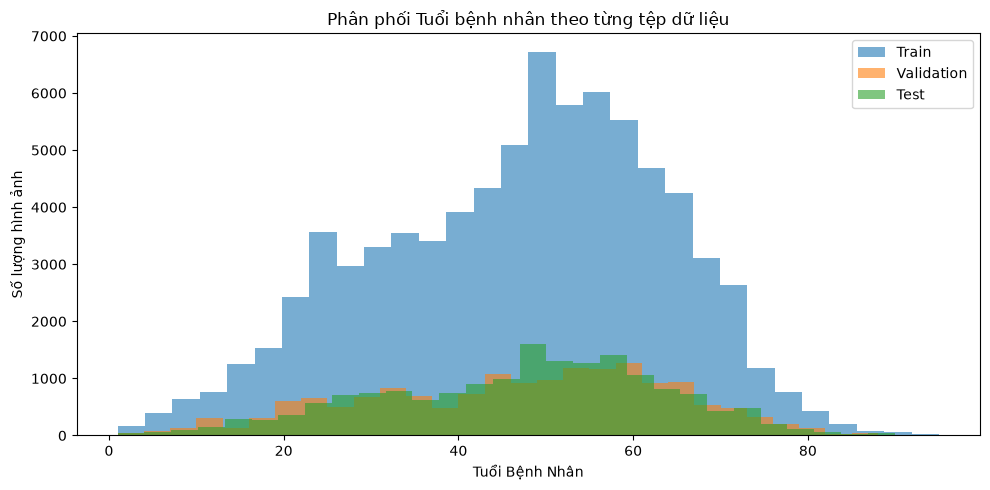

In [44]:
plt.figure(figsize=(10,5))
plt.hist(train_df["Patient Age"], bins=30, alpha=.6, label="Train")
plt.hist(val_df["Patient Age"], bins=30, alpha=.6, label="Validation")
plt.hist(test_df["Patient Age"], bins=30, alpha=.6, label="Test")
plt.xlabel("Tuổi Bệnh Nhân")
plt.ylabel("Số lượng hình ảnh")
plt.title("Phân phối Tuổi bệnh nhân theo từng tệp dữ liệu")
plt.legend()
plt.tight_layout()
plt.show()


> ## Quan sát một ảnh X-ray thực tế

Sau khi kiểm tra metadata, ta đọc thử một ảnh trực tiếp từ
`archive.zip`.

### Mục đích

Bước này xác nhận rằng:

- `Image Index` trong metadata ánh xạ đúng tới ảnh thật.
- `zip_member` trỏ tới đúng vị trí ảnh.
- File ảnh có thể được đọc trực tiếp từ ZIP.
- Ảnh X-ray có thể được PIL và Matplotlib xử lý bình thường.

Ảnh chỉ được đọc vào bộ nhớ khi cần và không được giải nén cố định
ra ổ đĩa.

Image Index: 00004832_032.png
Patient ID: 4832
Patient Age: 33
ZIP member: images_003/images/00004832_032.png


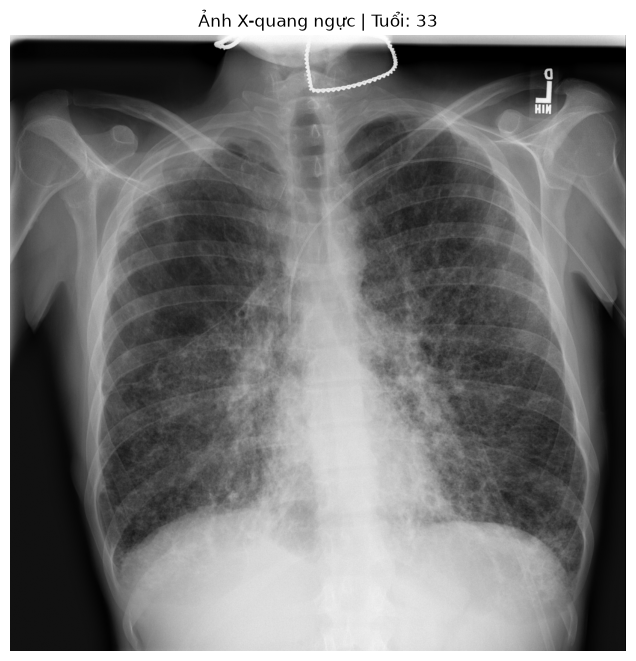

In [46]:


# Chọn một sample ngẫu nhiên từ train set
sample = train_df.sample(1, random_state=42).iloc[0]

image_index = sample["Image Index"]
zip_member = sample["zip_member"]
patient_age = sample["Patient Age"]

print("Image Index:", image_index)
print("Patient ID:", sample["Patient ID"])
print("Patient Age:", patient_age)
print("ZIP member:", zip_member)

# Đọc ảnh trực tiếp từ ZIP
with zipfile.ZipFile(ZIP_PATH, "r") as z:
    with z.open(zip_member) as f:
        image = Image.open(io.BytesIO(f.read())).convert("L")

plt.figure(figsize=(8, 8))
plt.imshow(image, cmap="gray")
plt.axis("off")
plt.title(f"Ảnh X-quang ngực | Tuổi: {patient_age}")
plt.show()

> ## Quan sát nhiều mẫu X-ray

Một ảnh duy nhất không đủ để đánh giá trực quan dataset. Vì vậy ta lấy
ngẫu nhiên nhiều sample từ tập Train để quan sát sự đa dạng của dữ liệu.

Mỗi ảnh được hiển thị cùng:

- Tuổi bệnh nhân.
- Patient ID.

Việc quan sát nhiều ảnh giúp kiểm tra trực quan chất lượng dữ liệu và
xác nhận rằng pipeline đang lấy ảnh từ nhiều bệnh nhân khác nhau.

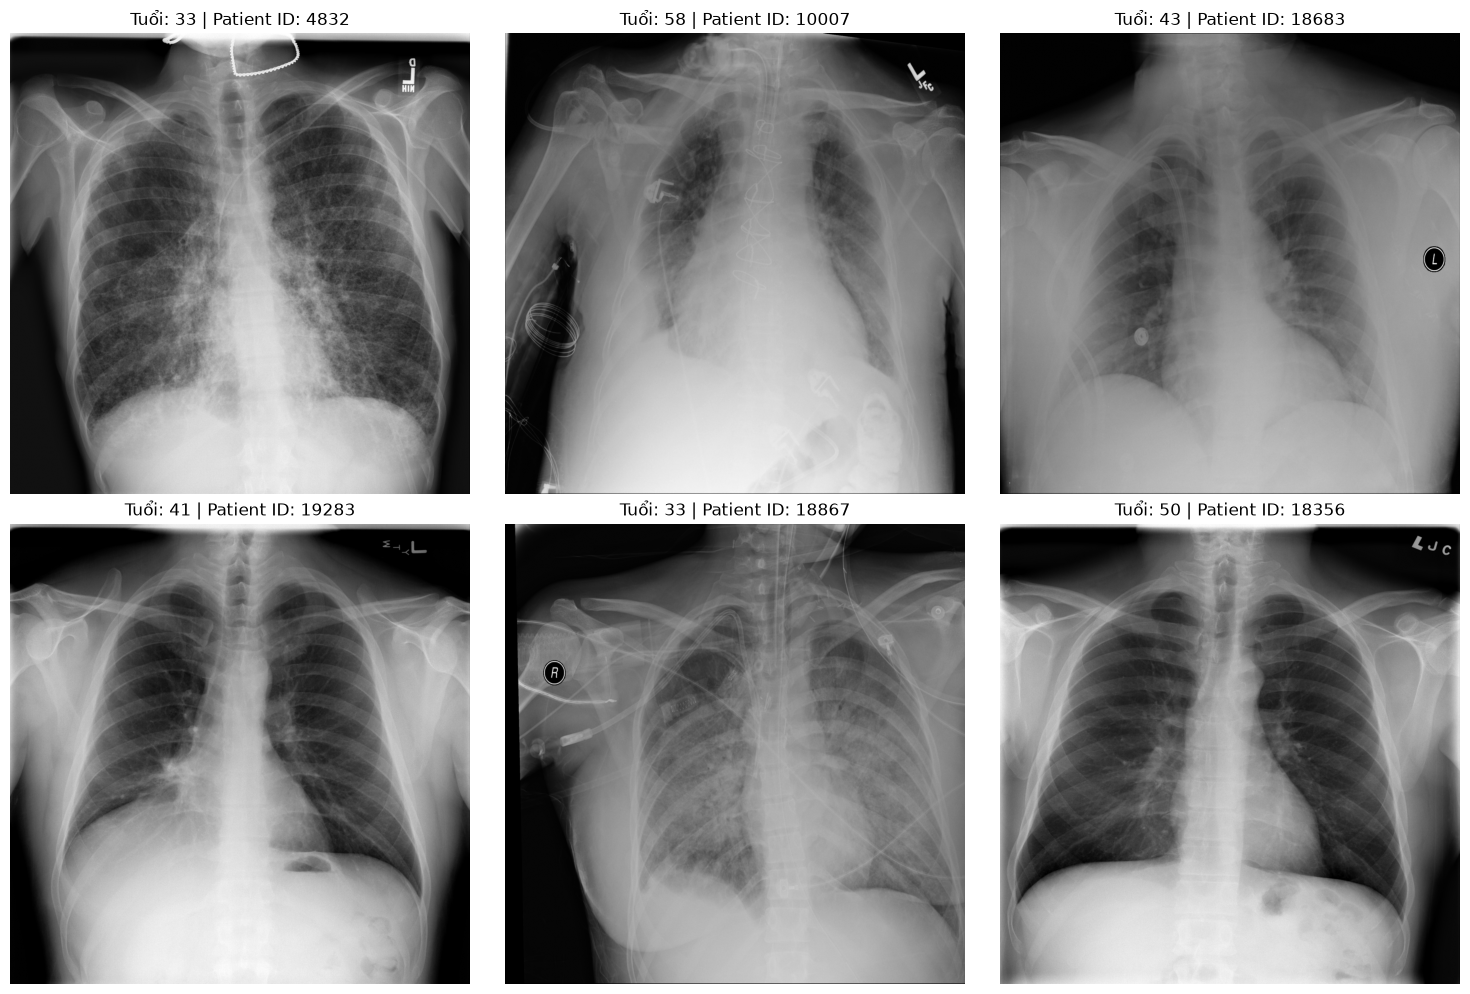

In [47]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

samples = train_df.sample(
    6,
    random_state=42
).reset_index(drop=True)

with zipfile.ZipFile(ZIP_PATH, "r") as z:

    for ax, (_, row) in zip(axes.flatten(), samples.iterrows()):

        with z.open(row["zip_member"]) as f:
            image = Image.open(
                io.BytesIO(f.read())
            ).convert("L")

        ax.imshow(image, cmap="gray")
        ax.axis("off")

        ax.set_title(
            f"Tuổi: {row['Patient Age']} | "
            f"Patient ID: {row['Patient ID']}"
        )

plt.tight_layout()
plt.show()

# 11. Tiền xử lý ảnh trước khi đưa vào CNN

Ảnh X-ray gốc chưa thể được đưa trực tiếp vào CNN dưới dạng file ảnh.
Ảnh cần được chuyển đổi thành tensor có kích thước và miền giá trị
thống nhất.

Pipeline preprocessing sử dụng:

`X-ray gốc → Grayscale → Resize 224×224 → Tensor → Normalize`

### Grayscale

Ảnh X-ray mang thông tin cường độ sáng nên được biểu diễn bằng một
channel.

Input sau bước này có dạng:

`[1, H, W]`

### Resize

Tất cả ảnh được đưa về:

`224 × 224`

để mỗi sample có cùng kích thước và có thể ghép thành batch.

### ToTensor

Ảnh PIL được chuyển thành PyTorch Tensor để có thể đưa vào neural
network.

### Normalize

Tensor được chuẩn hóa trước khi đưa vào CNN nhằm tạo miền giá trị đầu
vào ổn định hơn cho quá trình tối ưu.

> Original

In [39]:
with zipfile.ZipFile(ZIP_PATH, "r") as z:
    with z.open(zip_member) as f:
        original = Image.open(
            io.BytesIO(f.read())
        ).convert("L")

> Process

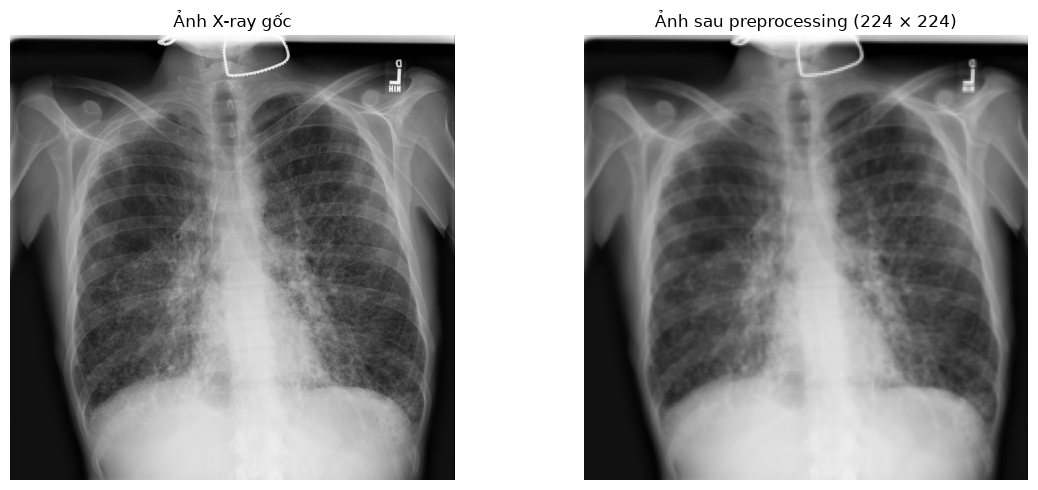

In [48]:
transform = default_transform(224)

processed = transform(original)

processed = (
    processed.squeeze(0)
    .numpy()
)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(original, cmap="gray")
plt.title("Ảnh X-ray gốc")
plt.axis("off")

plt.subplot(1, 2, 2)

# Denormalize để trực quan hóa
processed_display = processed * 0.5 + 0.5

plt.imshow(
    processed_display,
    cmap="gray"
)

plt.title("Ảnh sau preprocessing (224 × 224)")
plt.axis("off")
plt.tight_layout()
plt.show()

# 12. PyTorch Dataset và DataLoader

Sau khi preprocessing hoàn tất, dữ liệu được đóng gói thành PyTorch
`Dataset` và `DataLoader`.

## Dataset

`ZipChestXrayAgeDataset` chịu trách nhiệm:

1. Đọc một dòng từ CSV.
2. Lấy `zip_member`.
3. Đọc đúng ảnh từ `archive.zip`.
4. Chuyển ảnh sang grayscale.
5. Áp dụng preprocessing.
6. Trả về `(image, age)`.

Một sample có dạng:

`image: [1, 224, 224]`

`age: [1]`

## DataLoader

DataLoader gom nhiều sample thành một batch.

Với batch size `B`, output mong đợi:

`images: [B, 1, 224, 224]`

`ages: [B, 1]`

Trong đó:

- `B`: batch size.
- `1`: số channel của ảnh grayscale.
- `224 × 224`: chiều cao và chiều rộng ảnh.
- `[B, 1]`: target tuổi cho bài toán regression.

`num_workers=0` được sử dụng trước tiên vì ảnh đang được đọc trực tiếp
từ một file ZIP lớn. Đây là cấu hình đơn giản và ổn định để kiểm tra
pipeline trước khi tối ưu tốc độ đọc dữ liệu.

In [49]:
dataset = ZipChestXrayAgeDataset(
    PROCESSED_DIR/"train.csv",
    ZIP_PATH,
    transform=default_transform(224),
)

image, age = dataset[0]
print("Single image:", image.shape)
print("Single target:", age.shape)

loader = DataLoader(dataset, batch_size=8, shuffle=True, num_workers=0)
images, ages = next(iter(loader))

print("Batch images:", images.shape)
print("Batch ages:", ages.shape)

assert tuple(images.shape[1:]) == (1,224,224)
assert tuple(ages.shape[1:]) == (1,)
print("DATA pipeline sanity check passed.")


Single image: torch.Size([1, 224, 224])
Single target: torch.Size([1])
Batch images: torch.Size([8, 1, 224, 224])
Batch ages: torch.Size([8, 1])
DATA pipeline sanity check passed.


# 13. Tổng kết Pipeline Dataset & Preprocessing

Pipeline xử lý dữ liệu NIH ChestX-ray14 đã hoàn thành các bước:

- `<hoàn thành>` Đọc `Data_Entry_2017.csv` trực tiếp từ ZIP.
- `<hoàn thành>` Không cần giải nén toàn bộ dataset.
- `<hoàn thành>` Làm sạch `Patient Age`.
- `<hoàn thành>` Xác định vị trí của 112.120 ảnh bên trong ZIP.
- `<hoàn thành` Liên kết metadata với ảnh X-ray.
- `<hoàn thành>` Chia Train / Validation / Test theo Patient ID.
- `<hoàn thành>` Kiểm tra không có Patient ID leakage.
- `<hoàn thành>` Sinh `train.csv`, `val.csv`, `test.csv`.
- `<hoàn thành>` Thực hiện EDA cho phân phối tuổi và ảnh X-ray.
- `<hoàn thành>` Resize ảnh về 224 × 224.
- `<hoàn thành>` Chuyển ảnh thành grayscale tensor.
- `<hoàn thành>` Xây dựng PyTorch Dataset và DataLoader.
- `<hoàn thành>` Kiểm tra thành công shape đầu vào CNN.

## Output cuối cùng

**Image batch**

`[B, 1, 224, 224]`

**Regression target**

`[B, 1]`

Ba file `train.csv`, `val.csv` và `test.csv` được giữ cố định và sẽ
được sử dụng thống nhất cho các experiment tiếp theo.